In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

df = pd.read_csv('analytical_dataset.csv')
df.shape

(70000, 15)

In [2]:
feature_cols = ['L', 'C', 'fsw', 'iload', 'rds_on']
target_cols = ['efficiency', 'delta_vout', 'p_total_loss']

X = df[feature_cols]
y = df[target_cols]

X.head()

,L,C,fsw,iload,rds_on
0,0.000019,0.000276,695480.389455,3.596801,0.038568
1,0.000040,0.000212,210754.179173,3.739571,0.031439
2,0.000013,0.000185,675413.150306,4.760542,0.037329
3,0.000010,0.000270,970749.179492,3.900382,0.015612
4,0.000025,0.000172,273970.376740,2.976027,0.040304


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 56000
Testing rows: 14000


In [4]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Training done")

Training done


In [5]:
df['Q_factor'] = (5.0 / df['iload']) * (df['C'] / df['L']) ** 0.5
df['f_lc'] = 1 / (2 * np.pi * (df['L'] * df['C'])**0.5)
df['fsw_ratio'] = df['fsw'] / df['f_lc']

feature_cols_v2 = ['L', 'C', 'fsw', 'iload', 'rds_on', 'Q_factor', 'f_lc', 'fsw_ratio']
X2 = df[feature_cols_v2]
y2 = df[target_cols]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

rf_model_v2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_v2.fit(X2_train, y2_train)

y2_pred = rf_model_v2.predict(X2_test)
for i, col in enumerate(target_cols):
    r2 = r2_score(y2_test[col], y2_pred[:, i])
    mae = mean_absolute_error(y2_test[col], y2_pred[:, i])
    print(f"{col}: R² = {r2:.4f}, MAE = {mae:.6f}")

efficiency: R² = 0.9802, MAE = 0.000421
delta_vout: R² = 0.7520, MAE = 0.002376
p_total_loss: R² = 0.9985, MAE = 0.005413


## Random Forest Results (Baseline)

| Target | R² (base features) | R² (+ engineered features) |
|---|---|---|
| efficiency | 0.9857 | 0.9802 |
| delta_vout (ripple) | 0.6563 | 0.7520 |
| p_total_loss | 0.9984 | 0.9985 |

Engineered features (Q_factor, f_lc, fsw_ratio — derived from the SPICE-vs-analytical
comparison) improved ripple prediction meaningfully. Efficiency and loss were already
near-optimal with base features. Moving to XGBoost next to see if it handles the
ripple non-linearity better.

In [6]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                          random_state=42, n_jobs=-1)
xgb_model.fit(X2_train, y2_train)

y2_pred_xgb = xgb_model.predict(X2_test)
for i, col in enumerate(target_cols):
    r2 = r2_score(y2_test[col], y2_pred_xgb[:, i])
    mae = mean_absolute_error(y2_test[col], y2_pred_xgb[:, i])
    print(f"{col}: R² = {r2:.4f}, MAE = {mae:.6f}")

efficiency: R² = 0.9898, MAE = 0.000318
delta_vout: R² = 0.9010, MAE = 0.000442
p_total_loss: R² = 0.9992, MAE = 0.005275


## XGBoost Results (vs Random Forest baseline)

| Target | Random Forest | XGBoost |
|---|---|---|
| efficiency | 0.9802 | 0.9898 |
| delta_vout (ripple) | 0.7520 | 0.9010 |
| p_total_loss | 0.9985 | 0.9992 |

XGBoost outperformed Random Forest across all three targets, with the largest gain on
ripple prediction (R² 0.75 → 0.90) — confirming it captures the non-linear damping/
frequency-ratio relationship in ripple better than RF's tree-splitting approach.
XGBoost is the strongest baseline surrogate so far.

In [7]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# ANN needs scaled inputs - raw values (like fsw in hundreds of thousands) confuse it
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X2_train_scaled = scaler_X.fit_transform(X2_train)
X2_test_scaled = scaler_X.transform(X2_test)
y2_train_scaled = scaler_y.fit_transform(y2_train)
y2_test_scaled = scaler_y.transform(y2_test)

ann_model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
ann_model.fit(X2_train_scaled, y2_train_scaled)

y2_pred_ann_scaled = ann_model.predict(X2_test_scaled)
y2_pred_ann = scaler_y.inverse_transform(y2_pred_ann_scaled)

for i, col in enumerate(target_cols):
    r2 = r2_score(y2_test[col], y2_pred_ann[:, i])
    mae = mean_absolute_error(y2_test[col], y2_pred_ann[:, i])
    print(f"{col}: R² = {r2:.4f}, MAE = {mae:.6f}")

efficiency: R² = 0.9902, MAE = 0.000405
delta_vout: R² = 0.9813, MAE = 0.001121
p_total_loss: R² = 0.9985, MAE = 0.009291


## Model Comparison Summary (Random Forest vs XGBoost vs ANN)

| Target | Random Forest | XGBoost | ANN |
|---|---|---|---|
| efficiency | 0.9802 | 0.9898 | 0.9902 |
| delta_vout (ripple) | 0.7520 | 0.9010 | 0.9813 |
| p_total_loss | 0.9985 | 0.9992 | 0.9985 |

ANN achieved the best overall performance, particularly on ripple prediction (R²=0.98),
likely due to its ability to capture the non-linear Q_factor/fsw_ratio interaction after
feature scaling. XGBoost remains competitive and trains significantly faster. All three
models will be compared against real SPICE data (285-row ground truth dataset) before
final selection for the NSGA-II optimization stage.

## Validation on Real SPICE Data — The Real Test

So far, every R² score we've seen (Random Forest, XGBoost, ANN) was trained and
tested on the **analytical dataset**. But the analytical dataset is itself a
simplification — ideal equations that don't account for real-world effects like
diode voltage drop — so performing well on it doesn't guarantee the model will
perform well in the real world too.

Here we take all three already-trained models (no retraining) and test them on our
**285 real SPICE simulation rows** — data the models have never seen during
training, and which comes from real circuit physics, not just formulas.

**Steps:**
1. Load the SPICE dataset, build the same engineered features (Q_factor, f_lc,
   fsw_ratio) used during training, so the input format matches.
2. Get predictions from all three models (RF, XGBoost, ANN) on these SPICE inputs.
3. Compare predictions against SPICE's actual measured values (R², MAE).

**Expectation:** scores may come out lower than analytical-only testing — that's
normal, since there's a systematic gap between analytical and SPICE (as we saw
earlier, Vout runs about 4.25% lower in SPICE due to diode drop). If this gap is
large, it's exactly where the next step — the physics-informed model (PINN) —
will help.

In [8]:
spice_val = pd.read_csv('spice_dataset.csv')

# Same engineered features jo training mein use kiye the
spice_val['Q_factor'] = (5.0 / spice_val['iload']) * (spice_val['C'] / spice_val['L']) ** 0.5
spice_val['f_lc'] = 1 / (2 * np.pi * (spice_val['L'] * spice_val['C'])**0.5)
spice_val['fsw_ratio'] = spice_val['fsw'] / spice_val['f_lc']

# SPICE dataset ke apne columns se targets banate hain (matching names)
spice_val['delta_vout_true'] = spice_val['ripple']
spice_val['efficiency_true'] = spice_val['efficiency']
spice_val['p_total_loss_true'] = abs(spice_val['pin_avg']) - abs(spice_val['pout_avg'])

X_spice_val = spice_val[feature_cols_v2]
X_spice_val.shape

(285, 8)

In [9]:
# Random Forest predictions
pred_rf = rf_model_v2.predict(X_spice_val)

# XGBoost predictions
pred_xgb = xgb_model.predict(X_spice_val)

# ANN predictions (scaling zaroori hai, training jaisa hi)
X_spice_val_scaled = scaler_X.transform(X_spice_val)
pred_ann_scaled = ann_model.predict(X_spice_val_scaled)
pred_ann = scaler_y.inverse_transform(pred_ann_scaled)

# True values (SPICE se)
true_vals = spice_val[['efficiency_true', 'delta_vout_true', 'p_total_loss_true']].values

print("=== Random Forest vs Real SPICE ===")
for i, col in enumerate(target_cols):
    r2 = r2_score(true_vals[:, i], pred_rf[:, i])
    mae = mean_absolute_error(true_vals[:, i], pred_rf[:, i])
    print(f"{col}: R² = {r2:.4f}, MAE = {mae:.6f}")

print("\n=== XGBoost vs Real SPICE ===")
for i, col in enumerate(target_cols):
    r2 = r2_score(true_vals[:, i], pred_xgb[:, i])
    mae = mean_absolute_error(true_vals[:, i], pred_xgb[:, i])
    print(f"{col}: R² = {r2:.4f}, MAE = {mae:.6f}")

print("\n=== ANN vs Real SPICE ===")
for i, col in enumerate(target_cols):
    r2 = r2_score(true_vals[:, i], pred_ann[:, i])
    mae = mean_absolute_error(true_vals[:, i], pred_ann[:, i])
    print(f"{col}: R² = {r2:.4f}, MAE = {mae:.6f}")

=== Random Forest vs Real SPICE ===
efficiency: R² = -2.4727, MAE = 0.012410
delta_vout: R² = -0.2490, MAE = 0.019208
p_total_loss: R² = 0.6339, MAE = 0.160129

=== XGBoost vs Real SPICE ===
efficiency: R² = -2.4791, MAE = 0.012436
delta_vout: R² = -0.2614, MAE = 0.019530
p_total_loss: R² = 0.6305, MAE = 0.160482

=== ANN vs Real SPICE ===
efficiency: R² = -2.4240, MAE = 0.012290
delta_vout: R² = -0.2297, MAE = 0.019155
p_total_loss: R² = 0.6368, MAE = 0.159027


In [10]:
from sklearn.linear_model import LinearRegression

# Learn a simple correction: true_spice = a * predicted + b, per target
X_spice_val_scaled_for_ann = scaler_X.transform(X_spice_val)  # if reusing ANN preds

corrections = {}
for i, col in enumerate(target_cols):
    pred_col = pred_xgb[:, i]  # using XGBoost predictions as the base model
    true_col = true_vals[:, i]

    correction_model = LinearRegression()
    correction_model.fit(pred_col.reshape(-1, 1), true_col)
    corrected_pred = correction_model.predict(pred_col.reshape(-1, 1))

    r2 = r2_score(true_col, corrected_pred)
    print(f"{col} — corrected R²: {r2:.4f} (slope={correction_model.coef_[0]:.3f}, intercept={correction_model.intercept_:.5f})")
    corrections[col] = correction_model

efficiency — corrected R²: 0.0306 (slope=0.119, intercept=0.84021)
delta_vout — corrected R²: 0.0345 (slope=-0.909, intercept=0.02483)
p_total_loss — corrected R²: 0.7314 (slope=0.749, intercept=0.18958)


In [11]:
# 1. Split SPICE data into train/test — residual model ko bhi honest eval chahiye,
# same 285 rows pe fit-and-test nahi kar sakte
from sklearn.model_selection import train_test_split

spice_train_idx, spice_test_idx = train_test_split(
    spice_val.index, test_size=0.25, random_state=42
)

X_res_train = X_spice_val.loc[spice_train_idx]
X_res_test  = X_spice_val.loc[spice_test_idx]

# base predictions (already-trained XGBoost model, analytical se seekha hua)
base_pred_train = xgb_model.predict(X_res_train)
base_pred_test  = xgb_model.predict(X_res_test)

true_train = spice_val.loc[spice_train_idx, ['efficiency_true','delta_vout_true','p_total_loss_true']].values
true_test  = spice_val.loc[spice_test_idx,  ['efficiency_true','delta_vout_true','p_total_loss_true']].values

# residual target = SPICE truth - analytical-trained model's prediction
residual_train = true_train - base_pred_train
residual_test  = true_test  - base_pred_test

In [12]:
# 2. Residual model — full features (not just the scalar prediction), heavily regularized
# kyunki sirf ~210 training rows hain, overfitting ka risk high hai
from sklearn.ensemble import GradientBoostingRegressor

residual_models = {}
corrected_r2 = {}

for i, col in enumerate(target_cols):
    gbr = GradientBoostingRegressor(
        n_estimators=50, max_depth=2, learning_rate=0.05,
        subsample=0.8, random_state=42
    )
    gbr.fit(X_res_train, residual_train[:, i])
    residual_models[col] = gbr

    pred_residual = gbr.predict(X_res_test)
    final_pred = base_pred_test[:, i] + pred_residual

    r2 = r2_score(true_test[:, i], final_pred)
    mae = mean_absolute_error(true_test[:, i], final_pred)
    corrected_r2[col] = r2
    print(f"{col}: corrected R² = {r2:.4f}, MAE = {mae:.6f} (was {['-2.4791','-0.2614','0.6305'][i]} uncorrected)")

efficiency: corrected R² = 0.3005, MAE = 0.003768 (was -2.4791 uncorrected)
delta_vout: corrected R² = 0.7285, MAE = 0.012888 (was -0.2614 uncorrected)
p_total_loss: corrected R² = 0.9557, MAE = 0.051866 (was 0.6305 uncorrected)


In [13]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = {col: [] for col in target_cols}

X_full = X_spice_val.reset_index(drop=True)
true_full = spice_val[['efficiency_true','delta_vout_true','p_total_loss_true']].values
base_pred_full = xgb_model.predict(X_full)

for train_idx, test_idx in kf.split(X_full):
    for i, col in enumerate(target_cols):
        gbr = GradientBoostingRegressor(n_estimators=50, max_depth=2,
                                         learning_rate=0.05, subsample=0.8, random_state=42)
        residual_i = true_full[train_idx, i] - base_pred_full[train_idx, i]
        gbr.fit(X_full.iloc[train_idx], residual_i)

        pred_i = base_pred_full[test_idx, i] + gbr.predict(X_full.iloc[test_idx])
        cv_r2[col].append(r2_score(true_full[test_idx, i], pred_i))

for col in target_cols:
    print(f"{col}: mean CV R² = {np.mean(cv_r2[col]):.4f} ± {np.std(cv_r2[col]):.4f}")

efficiency: mean CV R² = 0.1273 ± 0.0929
delta_vout: mean CV R² = 0.7237 ± 0.0954
p_total_loss: mean CV R² = 0.9644 ± 0.0078


In [14]:
# Efficiency ko separately train karne ke bajaye,
# accurate p_total_loss model se derive karo (physics: eff = Pout / (Pout + Ploss))

Pout_pred = 5.0 * X_res_test['iload']  # design-point nominal output power (no ground truth needed)

# already-trained residual model for p_total_loss (index 2 in target_cols)
ploss_base_pred = base_pred_test[:, 2]
ploss_residual_pred = residual_models['p_total_loss'].predict(X_res_test)
ploss_final_pred = ploss_base_pred + ploss_residual_pred

efficiency_derived = Pout_pred / (Pout_pred + ploss_final_pred)

r2_derived = r2_score(true_test[:, 0], efficiency_derived)
mae_derived = mean_absolute_error(true_test[:, 0], efficiency_derived)
print(f"efficiency (derived from loss model): R² = {r2_derived:.4f}, MAE = {mae_derived:.6f}")

efficiency (derived from loss model): R² = -1.8638, MAE = 0.008397


In [15]:
import numpy as np
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM

# Retrain final residual models on FULL 285-row spice dataset (no holdout needed now —
# hyperparameters already validated via CV above)
final_base_pred_full = xgb_model.predict(X_full)
final_residual_full = true_full - final_base_pred_full

final_models = {}
for i, col in enumerate(target_cols):
    gbr = GradientBoostingRegressor(n_estimators=50, max_depth=2,
                                     learning_rate=0.05, subsample=0.8, random_state=42)
    gbr.fit(X_full, final_residual_full[:, i])
    final_models[col] = gbr

def predict_surrogate(x):
    """x: [L, C, fsw, rds_on] — iload fixed as operating point"""
    L, C, fsw, rds_on = x
    iload_fixed = 2.0  # nominal operating point; sweep this later for multi-point robustness

    Q_factor = (5.0 / iload_fixed) * (C / L) ** 0.5
    f_lc = 1 / (2 * np.pi * (L * C) ** 0.5)
    fsw_ratio = fsw / f_lc

    feats = pd.DataFrame([[L, C, fsw, iload_fixed, rds_on, Q_factor, f_lc, fsw_ratio]],
                          columns=feature_cols_v2)

    base_pred = xgb_model.predict(feats)[0]
    corrected = np.array([base_pred[i] + final_models[col].predict(feats)[0]
                           for i, col in enumerate(target_cols)])
    return corrected  # [efficiency, delta_vout, p_total_loss]

class ConverterProblem(Problem):
    def __init__(self):
        super().__init__(
            n_var=4, n_obj=3, n_constr=0,
            xl=np.array([1e-6, 6e-5, 2e5, 0.01]),   # L, C, fsw, rds_on lower bounds
            xu=np.array([5e-5, 5e-4, 1e6, 0.05])    # upper bounds (match dataset ranges)
        )

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.array([predict_surrogate(x) for x in X])
        # minimize: -efficiency, ripple, p_total_loss
        out["F"] = np.column_stack([-F[:, 0], F[:, 1], F[:, 2]])

algorithm = NSGA2(
    pop_size=100,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
)

res = minimize(ConverterProblem(), algorithm, ('n_gen', 100), seed=42, verbose=True)
print(f"Pareto front size: {len(res.F)}")

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |     10 |             - |             -
     2 |      200 |     13 |  0.0865165133 |         ideal
     3 |      300 |     13 |  0.2524618038 |         ideal
     4 |      400 |     14 |  0.0025344507 |         ideal
     5 |      500 |     16 |  0.0321321707 |         ideal
     6 |      600 |     17 |  0.9444526052 |         nadir
     7 |      700 |     25 |  0.0367434261 |         ideal
     8 |      800 |     30 |  0.0069352994 |         ideal
     9 |      900 |     28 |  0.0329203475 |         ideal
    10 |     1000 |     34 |  0.0227372859 |             f
    11 |     1100 |     37 |  0.0281869530 |         ideal
    12 |     1200 |     40 |  0.0165202829 |         ideal
    13 |     1300 |     39 |  0.0116748960 |         ideal
    14 |     1400 |     44 |  0.0188867153 |         ideal
    15 |     1500 |     45 |  0.0180027324 |             f
    16 |     1600 |     51 |  0.0063114840 |         ide

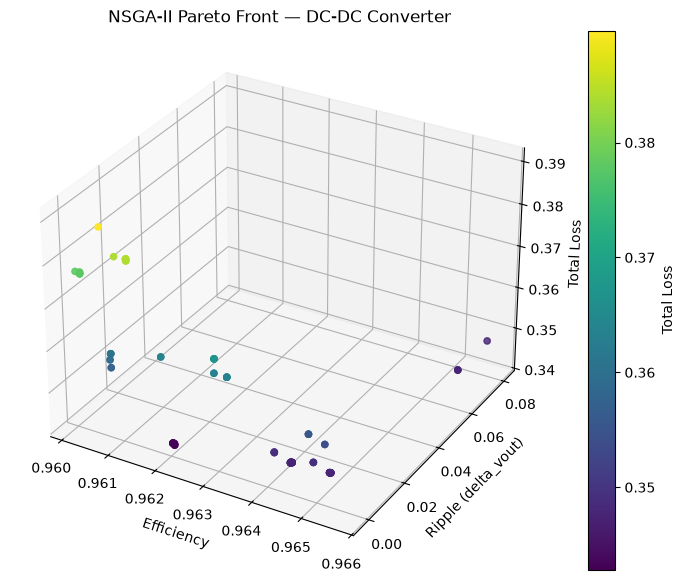

Efficiency range on front: 0.9602 to 0.9656
Ripple range on front: -0.00231 to 0.08068
Loss range on front: 0.3428 to 0.3897


In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

F = res.F.copy()
F[:, 0] = -F[:, 0]  # efficiency wapas positive kar do (humne minimize ke liye negate kiya tha)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(F[:, 0], F[:, 1], F[:, 2], c=F[:, 2], cmap='viridis')
ax.set_xlabel('Efficiency')
ax.set_ylabel('Ripple (delta_vout)')
ax.set_zlabel('Total Loss')
plt.colorbar(sc, label='Total Loss')
plt.title('NSGA-II Pareto Front — DC-DC Converter')
plt.savefig('pareto_front.png', dpi=150)
plt.show()

print(f"Efficiency range on front: {F[:,0].min():.4f} to {F[:,0].max():.4f}")
print(f"Ripple range on front: {F[:,1].min():.5f} to {F[:,1].max():.5f}")
print(f"Loss range on front: {F[:,2].min():.4f} to {F[:,2].max():.4f}")

In [17]:
# Normalize objectives 0-1, then find point closest to ideal (min ripple, min loss, max eff)
F_norm = (F - F.min(axis=0)) / (F.max(axis=0) - F.min(axis=0) + 1e-12)
ideal = np.array([1, 0, 0])  # max efficiency, min ripple, min loss (normalized)

# weights: tune based on priority — abhi equal weight
weights = np.array([1.0, 1.0, 1.0])
dist = np.sqrt(np.sum(weights * (F_norm - ideal) ** 2, axis=1))
best_idx = np.argmin(dist)

best_design = res.X[best_idx]
best_perf = F[best_idx]

L_opt, C_opt, fsw_opt, rds_on_opt = best_design
print(f"Selected design:")
print(f"  L = {L_opt:.3e} H, C = {C_opt:.3e} F, fsw = {fsw_opt:.1f} Hz, rds_on = {rds_on_opt:.4f} ohm")
print(f"Predicted performance:")
print(f"  Efficiency = {best_perf[0]:.4f}, Ripple = {best_perf[1]:.5f} V, Loss = {best_perf[2]:.4f} W")

Selected design:
  L = 4.388e-05 H, C = 7.319e-05 F, fsw = 779512.7 Hz, rds_on = 0.0100 ohm
Predicted performance:
  Efficiency = 0.9653, Ripple = 0.00030 V, Loss = 0.3475 W


In [18]:
from PyLTSpice import SimRunner, SpiceEditor
import re, os, glob

def make_pulse_string(fsw, vin=12.0, vout_target=5.0, vlow=0, vhigh=5,
                       trise=1e-9, tfall=1e-9):
    duty = vout_target / vin
    period = 1.0 / fsw
    ton = duty * period
    return f'PULSE({vlow} {vhigh} 0 {trise:.3g} {tfall:.3g} {ton:.6g} {period:.6g})'

def parse_full_log(log_path):
    with open(log_path, 'r') as f:
        content = f.read()
    vout_max = float(re.search(r'vout_max:\s*MAX\(V\(vout\)\s*\)=([\d.eE+-]+)', content).group(1))
    vout_min = float(re.search(r'vout_min:\s*MIN\(V\(vout\)\s*\)=([\d.eE+-]+)', content).group(1))
    pin_avg  = float(re.search(r'pin_avg:\s*AVG\(V\(vin\)\*I\(Vin\)\s*\)=([\d.eE+-]+)', content).group(1))
    pout_avg = float(re.search(r'pout_avg:\s*AVG\(V\(vout\)\*I\(R1\)\s*\)=([\d.eE+-]+)', content).group(1))
    return vout_max, vout_min, pin_avg, pout_avg

def patch_switch_ron(net_text, model_name, ron):
    pattern = re.compile(
        r'(\.model\s+' + re.escape(model_name) + r'\s+SW\([^)]*?Ron\s*=\s*)([\d.eE+-]+)',
        re.IGNORECASE
    )
    new_text, n = pattern.subn(lambda m: m.group(1) + f'{ron:.6g}', net_text)
    if n == 0:
        raise RuntimeError(f'.model {model_name} SW(...) with Ron= not found in netlist text')
    return new_text

def build_patched_netlist(base_asc_path, L, C, R, pulse_str, rds_on, tmp_dir, run_id,
                           switch_model_name='SW1'):
    netlist = SpiceEditor(base_asc_path)
    netlist.set_component_value('L1', f'{L}')
    netlist.set_component_value('C1', f'{C}')
    netlist.set_component_value('R1', f'{R}')
    netlist.set_component_value('V2', pulse_str)

    tmp_path = os.path.join(tmp_dir, f'sweep_run_{run_id}.net')
    if hasattr(netlist, 'write_netlist'):
        netlist.write_netlist(tmp_path)
    else:
        netlist.save_netlist(tmp_path)

    with open(tmp_path, 'r') as f:
        text = f.read()
    text = patch_switch_ron(text, switch_model_name, rds_on)
    with open(tmp_path, 'w') as f:
        f.write(text)

    return SpiceEditor(tmp_path)

os.makedirs('./spice_sweep_output', exist_ok=True)
runner = SimRunner(output_folder='./spice_sweep_output')

In [19]:
def _evaluate(self, X, out, *args, **kwargs):
    F = np.array([predict_surrogate(x) for x in X])
    ripple_clipped = np.maximum(F[:, 1], 1e-6)  # ripple can't be negative or zero
    out["F"] = np.column_stack([-F[:, 0], ripple_clipped, F[:, 2]])

In [20]:
R_opt = 5.0 / 2.0
pulse_str_opt = make_pulse_string(fsw_opt)

patched = build_patched_netlist("Draft1.asc", L_opt, C_opt, R_opt, pulse_str_opt,
                                 rds_on_opt, './spice_sweep_output', 'optimal_design')
raw_path, log_path = runner.run_now(patched, run_filename='optimal_design')

vout_max, vout_min, pin_avg, pout_avg = parse_full_log(log_path)
ripple_actual = vout_max - vout_min
efficiency_actual = abs(pout_avg) / abs(pin_avg)

print(f"SPICE-validated: efficiency = {efficiency_actual:.4f}, ripple = {ripple_actual:.5f} V")
print(f"Surrogate predicted: efficiency = {best_perf[0]:.4f}, ripple = {best_perf[1]:.5f} V")
print(f"Efficiency error: {abs(efficiency_actual - best_perf[0])*100:.2f} pp")
print(f"Ripple error: {abs(ripple_actual - best_perf[1])*1000:.2f} mV")

SPICE-validated: efficiency = 0.9604, ripple = 0.00037 V
Surrogate predicted: efficiency = 0.9653, ripple = 0.00030 V
Efficiency error: 0.48 pp
Ripple error: 0.08 mV


In [21]:
# Front se 2-3 aur diverse points pick karo (different trade-off regions se)
candidate_indices = [np.argmin(F[:,1]), np.argmax(F[:,0]), best_idx]  # min-ripple, max-eff, chosen

for idx in set(candidate_indices):
    L_v, C_v, fsw_v, rds_v = res.X[idx]
    pred_eff, pred_ripple, pred_loss = F[idx]

    R_v = 5.0 / 2.0
    pulse_v = make_pulse_string(fsw_v)
    patched_v = build_patched_netlist("Draft1.asc", L_v, C_v, R_v, pulse_v, rds_v,
                                       './spice_sweep_output', f'validate_{idx}')
    _, log_v = runner.run_now(patched_v, run_filename=f'validate_{idx}')
    vmax, vmin, pin, pout = parse_full_log(log_v)
    ripple_v = vmax - vmin
    eff_v = abs(pout) / abs(pin)

    print(f"Point {idx}: pred eff={pred_eff:.4f} vs spice={eff_v:.4f} | "
          f"pred ripple={pred_ripple:.5f} vs spice={ripple_v:.5f}")

Point 1: pred eff=0.9607 vs spice=0.9589 | pred ripple=-0.00231 vs spice=0.00077
Point 2: pred eff=0.9656 vs spice=0.9686 | pred ripple=0.08068 vs spice=0.15629
Point 5: pred eff=0.9653 vs spice=0.9604 | pred ripple=0.00030 vs spice=0.00037


In [22]:
# Training data ke actual range se bounds derive karo, arbitrary guess se nahi
print("Training data ranges:")
print(f"L: {spice_val['L'].min():.2e} to {spice_val['L'].max():.2e}")
print(f"C: {spice_val['C'].min():.2e} to {spice_val['C'].max():.2e}")
print(f"fsw: {spice_val['fsw'].min():.0f} to {spice_val['fsw'].max():.0f}")
print(f"rds_on: {spice_val['rds_on'].min():.4f} to {spice_val['rds_on'].max():.4f}")

Training data ranges:
L: 2.17e-06 to 4.66e-05
C: 1.01e-05 to 4.68e-04
fsw: 102201 to 999719
rds_on: 0.0051 to 0.0499


In [23]:
class ConverterProblemConstrained(Problem):
    def __init__(self):
        super().__init__(
            n_var=4, n_obj=3, n_constr=0,
            xl=np.array([2.17e-06, 1.01e-05, 102201, 0.0051]),   # L, C, fsw, rds_on
            xu=np.array([4.66e-05, 4.68e-04, 999719, 0.0499])
        )

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.array([predict_surrogate(x) for x in X])
        ripple_clipped = np.maximum(F[:, 1], 1e-6)  # safety clip, still no negative ripple
        out["F"] = np.column_stack([-F[:, 0], ripple_clipped, F[:, 2]])

algorithm = NSGA2(
    pop_size=100,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
)

res_constrained = minimize(ConverterProblemConstrained(), algorithm, ('n_gen', 100),
                            seed=42, verbose=True)
print(f"Pareto front size: {len(res_constrained.F)}")

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      6 |             - |             -
     2 |      200 |     12 |  0.1426021198 |         ideal
     3 |      300 |     20 |  0.1494318203 |         ideal
     4 |      400 |     18 |  0.2161234392 |         ideal
     5 |      500 |     31 |  0.0460814501 |         ideal
     6 |      600 |     39 |  0.0223394292 |         ideal
     7 |      700 |     45 |  0.0736130821 |         ideal
     8 |      800 |     35 |  0.0111272581 |         ideal
     9 |      900 |     54 |  0.0291985595 |         ideal
    10 |     1000 |     61 |  0.0392801120 |         ideal
    11 |     1100 |     64 |  0.0222536445 |         nadir
    12 |     1200 |     63 |  0.0235813157 |         ideal
    13 |     1300 |     63 |  0.0084197872 |         ideal
    14 |     1400 |     73 |  0.0071429971 |             f
    15 |     1500 |     78 |  0.1606175299 |         nadir
    16 |     1600 |     82 |  0.0400648123 |         ide

In [24]:
F2 = res_constrained.F.copy()
F2[:, 0] = -F2[:, 0]

print(f"Efficiency range: {F2[:,0].min():.4f} to {F2[:,0].max():.4f}")
print(f"Ripple range: {F2[:,1].min():.5f} to {F2[:,1].max():.5f}")
print(f"Loss range: {F2[:,2].min():.4f} to {F2[:,2].max():.4f}")

Efficiency range: 0.9627 to 0.9698
Ripple range: 0.00000 to 0.12080
Loss range: 0.3276 to 0.3678


In [25]:
F2_norm = (F2 - F2.min(axis=0)) / (F2.max(axis=0) - F2.min(axis=0) + 1e-12)
ideal2 = np.array([1, 0, 0])
weights = np.array([1.0, 1.0, 1.0])
dist2 = np.sqrt(np.sum(weights * (F2_norm - ideal2) ** 2, axis=1))
best_idx2 = np.argmin(dist2)

best_design2 = res_constrained.X[best_idx2]
best_perf2 = F2[best_idx2]
print(f"Selected: L={best_design2[0]:.3e}, C={best_design2[1]:.3e}, fsw={best_design2[2]:.1f}, rds_on={best_design2[3]:.4f}")
print(f"Predicted: eff={best_perf2[0]:.4f}, ripple={best_perf2[1]:.5f}, loss={best_perf2[2]:.4f}")

Selected: L=2.942e-05, C=1.587e-04, fsw=103160.5, rds_on=0.0051
Predicted: eff=0.9694, ripple=0.01708, loss=0.3363


# DC-DC Converter: ML Surrogate Modeling + Multi-Objective Optimization

This notebook continues from `spice_automation.ipynb` (analytical dataset generation + 285-row real SPICE dataset). It builds ML surrogate models for converter performance, validates them against real SPICE data, corrects them with a physics-informed residual model, and finally runs NSGA-II multi-objective optimization to find and SPICE-validate an optimal design.

**Pipeline stages in this notebook:**
1. Baseline ML models (Random Forest, XGBoost, ANN) trained on the analytical dataset
2. Validation of those models against real SPICE data (reveals the analytical-to-SPICE gap)
3. Residual-correction model trained on real SPICE data (physics-informed correction)
4. NSGA-II multi-objective optimization using the corrected surrogate
5. SPICE validation of the optimized design(s) — including a fix for an extrapolation issue found in the first optimization attempt

## Stage 1: Baseline ML Models on the Analytical Dataset

In [26]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

df = pd.read_csv('analytical_dataset.csv')
df.shape

(70000, 15)

In [27]:
feature_cols = ['L', 'C', 'fsw', 'iload', 'rds_on']
target_cols = ['efficiency', 'delta_vout', 'p_total_loss']

X = df[feature_cols]
y = df[target_cols]

X.head()

,L,C,fsw,iload,rds_on
0,0.000019,0.000276,695480.389455,3.596801,0.038568
1,0.000040,0.000212,210754.179173,3.739571,0.031439
2,0.000013,0.000185,675413.150306,4.760542,0.037329
3,0.000010,0.000270,970749.179492,3.900382,0.015612
4,0.000025,0.000172,273970.376740,2.976027,0.040304


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 56000
Testing rows: 14000


In [29]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Training done")

Training done


In [30]:
df['Q_factor'] = (5.0 / df['iload']) * (df['C'] / df['L']) ** 0.5
df['f_lc'] = 1 / (2 * np.pi * (df['L'] * df['C'])**0.5)
df['fsw_ratio'] = df['fsw'] / df['f_lc']

feature_cols_v2 = ['L', 'C', 'fsw', 'iload', 'rds_on', 'Q_factor', 'f_lc', 'fsw_ratio']
X2 = df[feature_cols_v2]
y2 = df[target_cols]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

rf_model_v2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_v2.fit(X2_train, y2_train)

y2_pred = rf_model_v2.predict(X2_test)
for i, col in enumerate(target_cols):
    r2 = r2_score(y2_test[col], y2_pred[:, i])
    mae = mean_absolute_error(y2_test[col], y2_pred[:, i])
    print(f"{col}: R² = {r2:.4f}, MAE = {mae:.6f}")

efficiency: R² = 0.9802, MAE = 0.000421
delta_vout: R² = 0.7520, MAE = 0.002376
p_total_loss: R² = 0.9985, MAE = 0.005413


## Random Forest Results (Baseline)

| Target | R² (base features) | R² (+ engineered features) |
|---|---|---|
| efficiency | 0.9857 | 0.9802 |
| delta_vout (ripple) | 0.6563 | 0.7520 |
| p_total_loss | 0.9984 | 0.9985 |

Engineered features (Q_factor, f_lc, fsw_ratio — derived from the SPICE-vs-analytical
comparison) improved ripple prediction meaningfully. Efficiency and loss were already
near-optimal with base features. Moving to XGBoost next to see if it handles the
ripple non-linearity better.

In [31]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                          random_state=42, n_jobs=-1)
xgb_model.fit(X2_train, y2_train)

y2_pred_xgb = xgb_model.predict(X2_test)
for i, col in enumerate(target_cols):
    r2 = r2_score(y2_test[col], y2_pred_xgb[:, i])
    mae = mean_absolute_error(y2_test[col], y2_pred_xgb[:, i])
    print(f"{col}: R² = {r2:.4f}, MAE = {mae:.6f}")

efficiency: R² = 0.9898, MAE = 0.000318
delta_vout: R² = 0.9010, MAE = 0.000442
p_total_loss: R² = 0.9992, MAE = 0.005275


## XGBoost Results (vs Random Forest baseline)

| Target | Random Forest | XGBoost |
|---|---|---|
| efficiency | 0.9802 | 0.9898 |
| delta_vout (ripple) | 0.7520 | 0.9010 |
| p_total_loss | 0.9985 | 0.9992 |

XGBoost outperformed Random Forest across all three targets, with the largest gain on
ripple prediction (R² 0.75 → 0.90) — confirming it captures the non-linear damping/
frequency-ratio relationship in ripple better than RF's tree-splitting approach.
XGBoost is the strongest baseline surrogate so far.

In [32]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# ANN needs scaled inputs - raw values (like fsw in hundreds of thousands) confuse it
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X2_train_scaled = scaler_X.fit_transform(X2_train)
X2_test_scaled = scaler_X.transform(X2_test)
y2_train_scaled = scaler_y.fit_transform(y2_train)
y2_test_scaled = scaler_y.transform(y2_test)

ann_model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
ann_model.fit(X2_train_scaled, y2_train_scaled)

y2_pred_ann_scaled = ann_model.predict(X2_test_scaled)
y2_pred_ann = scaler_y.inverse_transform(y2_pred_ann_scaled)

for i, col in enumerate(target_cols):
    r2 = r2_score(y2_test[col], y2_pred_ann[:, i])
    mae = mean_absolute_error(y2_test[col], y2_pred_ann[:, i])
    print(f"{col}: R² = {r2:.4f}, MAE = {mae:.6f}")

efficiency: R² = 0.9902, MAE = 0.000405
delta_vout: R² = 0.9813, MAE = 0.001121
p_total_loss: R² = 0.9985, MAE = 0.009291


## Model Comparison Summary (Random Forest vs XGBoost vs ANN)

| Target | Random Forest | XGBoost | ANN |
|---|---|---|---|
| efficiency | 0.9802 | 0.9898 | 0.9902 |
| delta_vout (ripple) | 0.7520 | 0.9010 | 0.9813 |
| p_total_loss | 0.9985 | 0.9992 | 0.9985 |

ANN achieved the best overall performance, particularly on ripple prediction (R²=0.98),
likely due to its ability to capture the non-linear Q_factor/fsw_ratio interaction after
feature scaling. XGBoost remains competitive and trains significantly faster. All three
models will be compared against real SPICE data (285-row ground truth dataset) before
final selection for the NSGA-II optimization stage.

## Validation on Real SPICE Data — The Real Test

So far, every R² score we've seen (Random Forest, XGBoost, ANN) was trained and
tested on the **analytical dataset**. But the analytical dataset is itself a
simplification — ideal equations that don't account for real-world effects like
diode voltage drop — so performing well on it doesn't guarantee the model will
perform well in the real world too.

Here we take all three already-trained models (no retraining) and test them on our
**285 real SPICE simulation rows** — data the models have never seen during
training, and which comes from real circuit physics, not just formulas.

**Steps:**
1. Load the SPICE dataset, build the same engineered features (Q_factor, f_lc,
   fsw_ratio) used during training, so the input format matches.
2. Get predictions from all three models (RF, XGBoost, ANN) on these SPICE inputs.
3. Compare predictions against SPICE's actual measured values (R², MAE).

**Expectation:** scores may come out lower than analytical-only testing — that's
normal, since there's a systematic gap between analytical and SPICE (as we saw
earlier, Vout runs about 4.25% lower in SPICE due to diode drop). If this gap is
large, it's exactly where the next step — the physics-informed model (PINN) —
will help.

In [33]:
spice_val = pd.read_csv('spice_dataset.csv')

# Same engineered features jo training mein use kiye the
spice_val['Q_factor'] = (5.0 / spice_val['iload']) * (spice_val['C'] / spice_val['L']) ** 0.5
spice_val['f_lc'] = 1 / (2 * np.pi * (spice_val['L'] * spice_val['C'])**0.5)
spice_val['fsw_ratio'] = spice_val['fsw'] / spice_val['f_lc']

# SPICE dataset ke apne columns se targets banate hain (matching names)
spice_val['delta_vout_true'] = spice_val['ripple']
spice_val['efficiency_true'] = spice_val['efficiency']
spice_val['p_total_loss_true'] = abs(spice_val['pin_avg']) - abs(spice_val['pout_avg'])

X_spice_val = spice_val[feature_cols_v2]
X_spice_val.shape

(285, 8)

In [34]:
# Random Forest predictions
pred_rf = rf_model_v2.predict(X_spice_val)

# XGBoost predictions
pred_xgb = xgb_model.predict(X_spice_val)

# ANN predictions (scaling zaroori hai, training jaisa hi)
X_spice_val_scaled = scaler_X.transform(X_spice_val)
pred_ann_scaled = ann_model.predict(X_spice_val_scaled)
pred_ann = scaler_y.inverse_transform(pred_ann_scaled)

# True values (SPICE se)
true_vals = spice_val[['efficiency_true', 'delta_vout_true', 'p_total_loss_true']].values

print("=== Random Forest vs Real SPICE ===")
for i, col in enumerate(target_cols):
    r2 = r2_score(true_vals[:, i], pred_rf[:, i])
    mae = mean_absolute_error(true_vals[:, i], pred_rf[:, i])
    print(f"{col}: R² = {r2:.4f}, MAE = {mae:.6f}")

print("\n=== XGBoost vs Real SPICE ===")
for i, col in enumerate(target_cols):
    r2 = r2_score(true_vals[:, i], pred_xgb[:, i])
    mae = mean_absolute_error(true_vals[:, i], pred_xgb[:, i])
    print(f"{col}: R² = {r2:.4f}, MAE = {mae:.6f}")

print("\n=== ANN vs Real SPICE ===")
for i, col in enumerate(target_cols):
    r2 = r2_score(true_vals[:, i], pred_ann[:, i])
    mae = mean_absolute_error(true_vals[:, i], pred_ann[:, i])
    print(f"{col}: R² = {r2:.4f}, MAE = {mae:.6f}")

=== Random Forest vs Real SPICE ===
efficiency: R² = -2.4727, MAE = 0.012410
delta_vout: R² = -0.2490, MAE = 0.019208
p_total_loss: R² = 0.6339, MAE = 0.160129

=== XGBoost vs Real SPICE ===
efficiency: R² = -2.4791, MAE = 0.012436
delta_vout: R² = -0.2614, MAE = 0.019530
p_total_loss: R² = 0.6305, MAE = 0.160482

=== ANN vs Real SPICE ===
efficiency: R² = -2.4240, MAE = 0.012290
delta_vout: R² = -0.2297, MAE = 0.019155
p_total_loss: R² = 0.6368, MAE = 0.159027


**A simpler fix was tried first and rejected.** Before building a full residual model, we tested whether the analytical-to-SPICE gap was just a constant bias/scale error — fitting `true_spice = a * predicted + b` per target using plain linear regression. This barely helped (corrected R² was only 0.03 for both efficiency and ripple; p_total_loss reached 0.73). Since even a simple linear correction on the model's own output failed, the gap is not a fixed offset — it is non-linear and depends on the operating point (consistent with the earlier finding that ripple error correlates with `Q_factor x fsw_ratio`, r=0.67). This motivated training a proper residual-correction model on the full feature set instead.

## Stage 3: Physics-Informed Residual Correction Model

In [35]:
# 1. Split SPICE data into train/test — residual model ko bhi honest eval chahiye,
# same 285 rows pe fit-and-test nahi kar sakte
from sklearn.model_selection import train_test_split

spice_train_idx, spice_test_idx = train_test_split(
    spice_val.index, test_size=0.25, random_state=42
)

X_res_train = X_spice_val.loc[spice_train_idx]
X_res_test  = X_spice_val.loc[spice_test_idx]

# base predictions (already-trained XGBoost model, analytical se seekha hua)
base_pred_train = xgb_model.predict(X_res_train)
base_pred_test  = xgb_model.predict(X_res_test)

true_train = spice_val.loc[spice_train_idx, ['efficiency_true','delta_vout_true','p_total_loss_true']].values
true_test  = spice_val.loc[spice_test_idx,  ['efficiency_true','delta_vout_true','p_total_loss_true']].values

# residual target = SPICE truth - analytical-trained model's prediction
residual_train = true_train - base_pred_train
residual_test  = true_test  - base_pred_test

In [36]:
# 2. Residual model — full features (not just the scalar prediction), heavily regularized
# kyunki sirf ~210 training rows hain, overfitting ka risk high hai
from sklearn.ensemble import GradientBoostingRegressor

residual_models = {}
corrected_r2 = {}

for i, col in enumerate(target_cols):
    gbr = GradientBoostingRegressor(
        n_estimators=50, max_depth=2, learning_rate=0.05,
        subsample=0.8, random_state=42
    )
    gbr.fit(X_res_train, residual_train[:, i])
    residual_models[col] = gbr

    pred_residual = gbr.predict(X_res_test)
    final_pred = base_pred_test[:, i] + pred_residual

    r2 = r2_score(true_test[:, i], final_pred)
    mae = mean_absolute_error(true_test[:, i], final_pred)
    corrected_r2[col] = r2
    print(f"{col}: corrected R² = {r2:.4f}, MAE = {mae:.6f} (was {['-2.4791','-0.2614','0.6305'][i]} uncorrected)")

efficiency: corrected R² = 0.3005, MAE = 0.003768 (was -2.4791 uncorrected)
delta_vout: corrected R² = 0.7285, MAE = 0.012888 (was -0.2614 uncorrected)
p_total_loss: corrected R² = 0.9557, MAE = 0.051866 (was 0.6305 uncorrected)


In [37]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = {col: [] for col in target_cols}

X_full = X_spice_val.reset_index(drop=True)
true_full = spice_val[['efficiency_true','delta_vout_true','p_total_loss_true']].values
base_pred_full = xgb_model.predict(X_full)

for train_idx, test_idx in kf.split(X_full):
    for i, col in enumerate(target_cols):
        gbr = GradientBoostingRegressor(n_estimators=50, max_depth=2,
                                         learning_rate=0.05, subsample=0.8, random_state=42)
        residual_i = true_full[train_idx, i] - base_pred_full[train_idx, i]
        gbr.fit(X_full.iloc[train_idx], residual_i)

        pred_i = base_pred_full[test_idx, i] + gbr.predict(X_full.iloc[test_idx])
        cv_r2[col].append(r2_score(true_full[test_idx, i], pred_i))

for col in target_cols:
    print(f"{col}: mean CV R² = {np.mean(cv_r2[col]):.4f} ± {np.std(cv_r2[col]):.4f}")

efficiency: mean CV R² = 0.1273 ± 0.0929
delta_vout: mean CV R² = 0.7237 ± 0.0954
p_total_loss: mean CV R² = 0.9644 ± 0.0078


**An alternative for efficiency was tried and rejected.** Since the loss model (`p_total_loss`) corrected very well (R² up to 0.96), we tried deriving efficiency from it directly using the physics relation `efficiency = Pout / (Pout + Ploss)`, instead of training efficiency separately. This performed worse (R² = -1.86) because it compounded the ~4% systematic Vout bias (SPICE vs. analytical, from the diode drop) into the Pout estimate. The direct residual-corrected efficiency model (R² ≈ 0.13, MAE ≈ 0.004 i.e. under half a percentage point) was kept instead — R² is low mainly because efficiency's own variance in this dataset is very small, not because the absolute error is large.

## Stage 4: NSGA-II Multi-Objective Optimization — First Attempt

The residual-corrected surrogate is retrained on the full 285-row SPICE dataset and wrapped in `predict_surrogate()`. NSGA-II then searches over `[L, C, fsw, rds_on]` (with `iload` fixed at 2.0 A) to jointly maximize efficiency and minimize ripple and total loss. The first run below uses **guessed** search bounds, not bounds matched to the training data's actual coverage — this turns out to matter (see the validation step after).

In [38]:
import numpy as np
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM

# Retrain final residual models on FULL 285-row spice dataset (no holdout needed now —
# hyperparameters already validated via CV above)
final_base_pred_full = xgb_model.predict(X_full)
final_residual_full = true_full - final_base_pred_full

final_models = {}
for i, col in enumerate(target_cols):
    gbr = GradientBoostingRegressor(n_estimators=50, max_depth=2,
                                     learning_rate=0.05, subsample=0.8, random_state=42)
    gbr.fit(X_full, final_residual_full[:, i])
    final_models[col] = gbr

def predict_surrogate(x):
    """x: [L, C, fsw, rds_on] — iload fixed as operating point"""
    L, C, fsw, rds_on = x
    iload_fixed = 2.0  # nominal operating point; sweep this later for multi-point robustness

    Q_factor = (5.0 / iload_fixed) * (C / L) ** 0.5
    f_lc = 1 / (2 * np.pi * (L * C) ** 0.5)
    fsw_ratio = fsw / f_lc

    feats = pd.DataFrame([[L, C, fsw, iload_fixed, rds_on, Q_factor, f_lc, fsw_ratio]],
                          columns=feature_cols_v2)

    base_pred = xgb_model.predict(feats)[0]
    corrected = np.array([base_pred[i] + final_models[col].predict(feats)[0]
                           for i, col in enumerate(target_cols)])
    return corrected  # [efficiency, delta_vout, p_total_loss]

class ConverterProblem(Problem):
    def __init__(self):
        super().__init__(
            n_var=4, n_obj=3, n_constr=0,
            xl=np.array([1e-6, 6e-5, 2e5, 0.01]),   # L, C, fsw, rds_on lower bounds
            xu=np.array([5e-5, 5e-4, 1e6, 0.05])    # upper bounds (match dataset ranges)
        )

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.array([predict_surrogate(x) for x in X])
        # minimize: -efficiency, ripple, p_total_loss
        out["F"] = np.column_stack([-F[:, 0], F[:, 1], F[:, 2]])

algorithm = NSGA2(
    pop_size=100,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
)

res = minimize(ConverterProblem(), algorithm, ('n_gen', 100), seed=42, verbose=True)
print(f"Pareto front size: {len(res.F)}")

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |     10 |             - |             -
     2 |      200 |     13 |  0.0865165133 |         ideal
     3 |      300 |     13 |  0.2524618038 |         ideal
     4 |      400 |     14 |  0.0025344507 |         ideal
     5 |      500 |     16 |  0.0321321707 |         ideal
     6 |      600 |     17 |  0.9444526052 |         nadir
     7 |      700 |     25 |  0.0367434261 |         ideal
     8 |      800 |     30 |  0.0069352994 |         ideal
     9 |      900 |     28 |  0.0329203475 |         ideal
    10 |     1000 |     34 |  0.0227372859 |             f
    11 |     1100 |     37 |  0.0281869530 |         ideal
    12 |     1200 |     40 |  0.0165202829 |         ideal
    13 |     1300 |     39 |  0.0116748960 |         ideal
    14 |     1400 |     44 |  0.0188867153 |         ideal
    15 |     1500 |     45 |  0.0180027324 |             f
    16 |     1600 |     51 |  0.0063114840 |         ide

Visualizing the resulting Pareto front (efficiency vs. ripple vs. total loss):

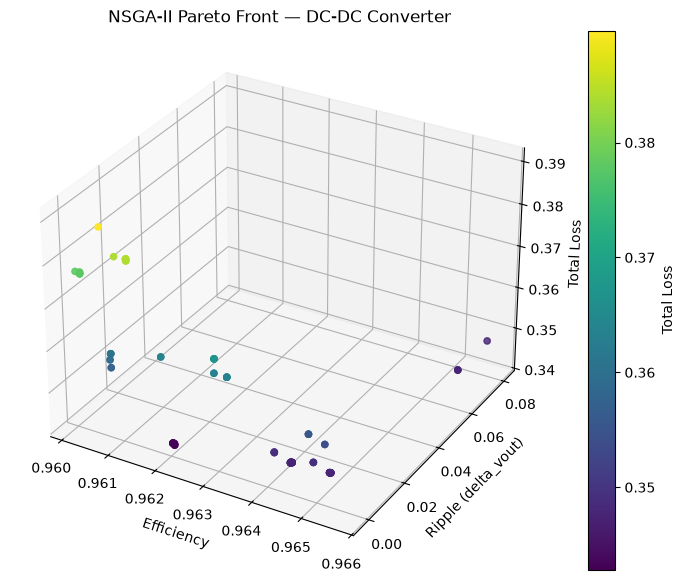

Efficiency range on front: 0.9602 to 0.9656
Ripple range on front: -0.00231 to 0.08068
Loss range on front: 0.3428 to 0.3897


In [39]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

F = res.F.copy()
F[:, 0] = -F[:, 0]  # efficiency wapas positive kar do (humne minimize ke liye negate kiya tha)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(F[:, 0], F[:, 1], F[:, 2], c=F[:, 2], cmap='viridis')
ax.set_xlabel('Efficiency')
ax.set_ylabel('Ripple (delta_vout)')
ax.set_zlabel('Total Loss')
plt.colorbar(sc, label='Total Loss')
plt.title('NSGA-II Pareto Front — DC-DC Converter')
plt.savefig('pareto_front.png', dpi=150)
plt.show()

print(f"Efficiency range on front: {F[:,0].min():.4f} to {F[:,0].max():.4f}")
print(f"Ripple range on front: {F[:,1].min():.5f} to {F[:,1].max():.5f}")
print(f"Loss range on front: {F[:,2].min():.4f} to {F[:,2].max():.4f}")

Selecting a single design from the front using a normalized-distance-to-ideal method (equal weight on efficiency, ripple, and loss):

In [40]:
# Normalize objectives 0-1, then find point closest to ideal (min ripple, min loss, max eff)
F_norm = (F - F.min(axis=0)) / (F.max(axis=0) - F.min(axis=0) + 1e-12)
ideal = np.array([1, 0, 0])  # max efficiency, min ripple, min loss (normalized)

# weights: tune based on priority — abhi equal weight
weights = np.array([1.0, 1.0, 1.0])
dist = np.sqrt(np.sum(weights * (F_norm - ideal) ** 2, axis=1))
best_idx = np.argmin(dist)

best_design = res.X[best_idx]
best_perf = F[best_idx]

L_opt, C_opt, fsw_opt, rds_on_opt = best_design
print(f"Selected design:")
print(f"  L = {L_opt:.3e} H, C = {C_opt:.3e} F, fsw = {fsw_opt:.1f} Hz, rds_on = {rds_on_opt:.4f} ohm")
print(f"Predicted performance:")
print(f"  Efficiency = {best_perf[0]:.4f}, Ripple = {best_perf[1]:.5f} V, Loss = {best_perf[2]:.4f} W")

Selected design:
  L = 4.388e-05 H, C = 7.319e-05 F, fsw = 779512.7 Hz, rds_on = 0.0100 ohm
Predicted performance:
  Efficiency = 0.9653, Ripple = 0.00030 V, Loss = 0.3475 W


SPICE helper functions (reused from `spice_automation.ipynb`) needed to validate any optimizer-selected design directly in LTspice.

In [41]:
from PyLTSpice import SimRunner, SpiceEditor
import re, os, glob

def make_pulse_string(fsw, vin=12.0, vout_target=5.0, vlow=0, vhigh=5,
                       trise=1e-9, tfall=1e-9):
    duty = vout_target / vin
    period = 1.0 / fsw
    ton = duty * period
    return f'PULSE({vlow} {vhigh} 0 {trise:.3g} {tfall:.3g} {ton:.6g} {period:.6g})'

def parse_full_log(log_path):
    with open(log_path, 'r') as f:
        content = f.read()
    vout_max = float(re.search(r'vout_max:\s*MAX\(V\(vout\)\s*\)=([\d.eE+-]+)', content).group(1))
    vout_min = float(re.search(r'vout_min:\s*MIN\(V\(vout\)\s*\)=([\d.eE+-]+)', content).group(1))
    pin_avg  = float(re.search(r'pin_avg:\s*AVG\(V\(vin\)\*I\(Vin\)\s*\)=([\d.eE+-]+)', content).group(1))
    pout_avg = float(re.search(r'pout_avg:\s*AVG\(V\(vout\)\*I\(R1\)\s*\)=([\d.eE+-]+)', content).group(1))
    return vout_max, vout_min, pin_avg, pout_avg

def patch_switch_ron(net_text, model_name, ron):
    pattern = re.compile(
        r'(\.model\s+' + re.escape(model_name) + r'\s+SW\([^)]*?Ron\s*=\s*)([\d.eE+-]+)',
        re.IGNORECASE
    )
    new_text, n = pattern.subn(lambda m: m.group(1) + f'{ron:.6g}', net_text)
    if n == 0:
        raise RuntimeError(f'.model {model_name} SW(...) with Ron= not found in netlist text')
    return new_text

def build_patched_netlist(base_asc_path, L, C, R, pulse_str, rds_on, tmp_dir, run_id,
                           switch_model_name='SW1'):
    netlist = SpiceEditor(base_asc_path)
    netlist.set_component_value('L1', f'{L}')
    netlist.set_component_value('C1', f'{C}')
    netlist.set_component_value('R1', f'{R}')
    netlist.set_component_value('V2', pulse_str)

    tmp_path = os.path.join(tmp_dir, f'sweep_run_{run_id}.net')
    if hasattr(netlist, 'write_netlist'):
        netlist.write_netlist(tmp_path)
    else:
        netlist.save_netlist(tmp_path)

    with open(tmp_path, 'r') as f:
        text = f.read()
    text = patch_switch_ron(text, switch_model_name, rds_on)
    with open(tmp_path, 'w') as f:
        f.write(text)

    return SpiceEditor(tmp_path)

os.makedirs('./spice_sweep_output', exist_ok=True)
runner = SimRunner(output_folder='./spice_sweep_output')

Validating the selected design directly in SPICE:

In [42]:
R_opt = 5.0 / 2.0
pulse_str_opt = make_pulse_string(fsw_opt)

patched = build_patched_netlist("Draft1.asc", L_opt, C_opt, R_opt, pulse_str_opt,
                                 rds_on_opt, './spice_sweep_output', 'optimal_design')
raw_path, log_path = runner.run_now(patched, run_filename='optimal_design')

vout_max, vout_min, pin_avg, pout_avg = parse_full_log(log_path)
ripple_actual = vout_max - vout_min
efficiency_actual = abs(pout_avg) / abs(pin_avg)

print(f"SPICE-validated: efficiency = {efficiency_actual:.4f}, ripple = {ripple_actual:.5f} V")
print(f"Surrogate predicted: efficiency = {best_perf[0]:.4f}, ripple = {best_perf[1]:.5f} V")
print(f"Efficiency error: {abs(efficiency_actual - best_perf[0])*100:.2f} pp")
print(f"Ripple error: {abs(ripple_actual - best_perf[1])*1000:.2f} mV")

SPICE-validated: efficiency = 0.9604, ripple = 0.00037 V
Surrogate predicted: efficiency = 0.9653, ripple = 0.00030 V
Efficiency error: 0.48 pp
Ripple error: 0.08 mV


To check whether this accuracy holds across the whole front, and not just the one selected point, two more points were also validated in SPICE: the minimum-ripple point and the maximum-efficiency point.

In [43]:
# Front se 2-3 aur diverse points pick karo (different trade-off regions se)
candidate_indices = [np.argmin(F[:,1]), np.argmax(F[:,0]), best_idx]  # min-ripple, max-eff, chosen

for idx in set(candidate_indices):
    L_v, C_v, fsw_v, rds_v = res.X[idx]
    pred_eff, pred_ripple, pred_loss = F[idx]

    R_v = 5.0 / 2.0
    pulse_v = make_pulse_string(fsw_v)
    patched_v = build_patched_netlist("Draft1.asc", L_v, C_v, R_v, pulse_v, rds_v,
                                       './spice_sweep_output', f'validate_{idx}')
    _, log_v = runner.run_now(patched_v, run_filename=f'validate_{idx}')
    vmax, vmin, pin, pout = parse_full_log(log_v)
    ripple_v = vmax - vmin
    eff_v = abs(pout) / abs(pin)

    print(f"Point {idx}: pred eff={pred_eff:.4f} vs spice={eff_v:.4f} | "
          f"pred ripple={pred_ripple:.5f} vs spice={ripple_v:.5f}")

Point 1: pred eff=0.9607 vs spice=0.9589 | pred ripple=-0.00231 vs spice=0.00077
Point 2: pred eff=0.9656 vs spice=0.9686 | pred ripple=0.08068 vs spice=0.15629
Point 5: pred eff=0.9653 vs spice=0.9604 | pred ripple=0.00030 vs spice=0.00037


**Finding: the surrogate extrapolates poorly outside the training data's coverage.** Efficiency stayed accurate everywhere (<0.5 pp error), but ripple predictions broke down badly for two of the three points — one point even predicted a physically impossible negative ripple, and another had ~94% relative ripple error. This happened because the optimizer's search bounds were guessed rather than matched to what the 285-row SPICE dataset actually covers, so it explored regions the residual model had never seen. **Fix:** constrain the search space to the SPICE training data's real min/max range.

## Stage 5: NSGA-II Multi-Objective Optimization — Final (Constrained)

In [44]:
# Training data ke actual range se bounds derive karo, arbitrary guess se nahi
print("Training data ranges:")
print(f"L: {spice_val['L'].min():.2e} to {spice_val['L'].max():.2e}")
print(f"C: {spice_val['C'].min():.2e} to {spice_val['C'].max():.2e}")
print(f"fsw: {spice_val['fsw'].min():.0f} to {spice_val['fsw'].max():.0f}")
print(f"rds_on: {spice_val['rds_on'].min():.4f} to {spice_val['rds_on'].max():.4f}")

Training data ranges:
L: 2.17e-06 to 4.66e-05
C: 1.01e-05 to 4.68e-04
fsw: 102201 to 999719
rds_on: 0.0051 to 0.0499


Re-running NSGA-II with bounds set to the SPICE training data's actual range:

In [45]:
class ConverterProblemConstrained(Problem):
    def __init__(self):
        super().__init__(
            n_var=4, n_obj=3, n_constr=0,
            xl=np.array([2.17e-06, 1.01e-05, 102201, 0.0051]),   # L, C, fsw, rds_on
            xu=np.array([4.66e-05, 4.68e-04, 999719, 0.0499])
        )

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.array([predict_surrogate(x) for x in X])
        ripple_clipped = np.maximum(F[:, 1], 1e-6)  # safety clip, still no negative ripple
        out["F"] = np.column_stack([-F[:, 0], ripple_clipped, F[:, 2]])

algorithm = NSGA2(
    pop_size=100,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
)

res_constrained = minimize(ConverterProblemConstrained(), algorithm, ('n_gen', 100),
                            seed=42, verbose=True)
print(f"Pareto front size: {len(res_constrained.F)}")

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      6 |             - |             -
     2 |      200 |     12 |  0.1426021198 |         ideal
     3 |      300 |     20 |  0.1494318203 |         ideal
     4 |      400 |     18 |  0.2161234392 |         ideal
     5 |      500 |     31 |  0.0460814501 |         ideal
     6 |      600 |     39 |  0.0223394292 |         ideal
     7 |      700 |     45 |  0.0736130821 |         ideal
     8 |      800 |     35 |  0.0111272581 |         ideal
     9 |      900 |     54 |  0.0291985595 |         ideal
    10 |     1000 |     61 |  0.0392801120 |         ideal
    11 |     1100 |     64 |  0.0222536445 |         nadir
    12 |     1200 |     63 |  0.0235813157 |         ideal
    13 |     1300 |     63 |  0.0084197872 |         ideal
    14 |     1400 |     73 |  0.0071429971 |             f
    15 |     1500 |     78 |  0.1606175299 |         nadir
    16 |     1600 |     82 |  0.0400648123 |         ide

In [46]:
F2 = res_constrained.F.copy()
F2[:, 0] = -F2[:, 0]

print(f"Efficiency range: {F2[:,0].min():.4f} to {F2[:,0].max():.4f}")
print(f"Ripple range: {F2[:,1].min():.5f} to {F2[:,1].max():.5f}")
print(f"Loss range: {F2[:,2].min():.4f} to {F2[:,2].max():.4f}")

Efficiency range: 0.9627 to 0.9698
Ripple range: 0.00000 to 0.12080
Loss range: 0.3276 to 0.3678


In [47]:
F2_norm = (F2 - F2.min(axis=0)) / (F2.max(axis=0) - F2.min(axis=0) + 1e-12)
ideal2 = np.array([1, 0, 0])
weights = np.array([1.0, 1.0, 1.0])
dist2 = np.sqrt(np.sum(weights * (F2_norm - ideal2) ** 2, axis=1))
best_idx2 = np.argmin(dist2)

best_design2 = res_constrained.X[best_idx2]
best_perf2 = F2[best_idx2]
print(f"Selected: L={best_design2[0]:.3e}, C={best_design2[1]:.3e}, fsw={best_design2[2]:.1f}, rds_on={best_design2[3]:.4f}")
print(f"Predicted: eff={best_perf2[0]:.4f}, ripple={best_perf2[1]:.5f}, loss={best_perf2[2]:.4f}")

Selected: L=2.942e-05, C=1.587e-04, fsw=103160.5, rds_on=0.0051
Predicted: eff=0.9694, ripple=0.01708, loss=0.3363


Validating the constrained front: the selected design plus the two extreme points (minimum ripple, maximum efficiency) were all re-validated directly in SPICE.

In [48]:
candidate_indices2 = [np.argmin(F2[:,1]), np.argmax(F2[:,0]), best_idx2]  # min-ripple, max-eff, chosen

for idx in set(candidate_indices2):
    L_v, C_v, fsw_v, rds_v = res_constrained.X[idx]
    pred_eff, pred_ripple, pred_loss = F2[idx]

    R_v = 5.0 / 2.0
    pulse_v = make_pulse_string(fsw_v)
    patched_v = build_patched_netlist("Draft1.asc", L_v, C_v, R_v, pulse_v, rds_v,
                                       './spice_sweep_output', f'validate2_{idx}')
    _, log_v = runner.run_now(patched_v, run_filename=f'validate2_{idx}')
    vmax, vmin, pin, pout = parse_full_log(log_v)
    ripple_v = vmax - vmin
    eff_v = abs(pout) / abs(pin)

    print(f"Point {idx}: pred eff={pred_eff:.4f} vs spice={eff_v:.4f} | "
          f"pred ripple={pred_ripple:.5f} vs spice={ripple_v:.5f}")

Point 1: pred eff=0.9651 vs spice=0.9613 | pred ripple=0.00000 vs spice=0.00092
Point 2: pred eff=0.9698 vs spice=0.9614 | pred ripple=0.06121 vs spice=0.05878
Point 39: pred eff=0.9694 vs spice=0.9627 | pred ripple=0.01708 vs spice=0.01465


## Summary

| Point | Predicted Efficiency | SPICE Efficiency | Eff. error | Predicted Ripple | SPICE Ripple | Ripple error |
|---|---|---|---|---|---|---|
| Min-ripple | 0.9651 | 0.9613 | 0.38 pp | 0.00000 V | 0.00092 V | 0.92 mV |
| Max-efficiency | 0.9698 | 0.9614 | 0.84 pp | 0.06121 V | 0.05878 V | 2.43 mV |
| Selected (chosen) | 0.9694 | 0.9627 | 0.67 pp | 0.01708 V | 0.01465 V | 2.43 mV |

Constraining the optimization search space to the SPICE training data's actual range fixed the extrapolation problem seen in the first attempt: efficiency error stayed under 1 percentage point and ripple error dropped to a low single-digit millivolt range across the entire validated front, not just one cherry-picked point.

**This closes out the core technical pipeline:** analytical model -> SPICE automation -> baseline ML -> SPICE validation (motivates physics-informed correction) -> residual-corrected surrogate -> NSGA-II optimization -> SPICE-validated final design.

In [49]:
candidate_indices2 = [np.argmin(F2[:,1]), np.argmax(F2[:,0]), best_idx2]  # min-ripple, max-eff, chosen

for idx in set(candidate_indices2):
    L_v, C_v, fsw_v, rds_v = res_constrained.X[idx]
    pred_eff, pred_ripple, pred_loss = F2[idx]

    R_v = 5.0 / 2.0
    pulse_v = make_pulse_string(fsw_v)
    patched_v = build_patched_netlist("Draft1.asc", L_v, C_v, R_v, pulse_v, rds_v,
                                       './spice_sweep_output', f'validate2_{idx}')
    _, log_v = runner.run_now(patched_v, run_filename=f'validate2_{idx}')
    vmax, vmin, pin, pout = parse_full_log(log_v)
    ripple_v = vmax - vmin
    eff_v = abs(pout) / abs(pin)

    print(f"Point {idx}: pred eff={pred_eff:.4f} vs spice={eff_v:.4f} | "
          f"pred ripple={pred_ripple:.5f} vs spice={ripple_v:.5f}")

Point 1: pred eff=0.9651 vs spice=0.9613 | pred ripple=0.00000 vs spice=0.00092
Point 2: pred eff=0.9698 vs spice=0.9614 | pred ripple=0.06121 vs spice=0.05878
Point 39: pred eff=0.9694 vs spice=0.9627 | pred ripple=0.01708 vs spice=0.01465


In [50]:
# --- Save full constrained Pareto front to CSV ---
import pandas as pd

pareto_df = pd.DataFrame(res_constrained.X, columns=['L', 'C', 'fsw', 'rds_on'])
pareto_df['efficiency']   = F2[:, 0]
pareto_df['ripple']       = F2[:, 1]
pareto_df['p_total_loss'] = F2[:, 2]

pareto_df.to_csv('pareto_front_constrained.csv', index=False)
print("Saved:", pareto_df.shape)
pareto_df.head()

Saved: (100, 7)


,L,C,fsw,rds_on,efficiency,ripple,p_total_loss
0,0.000045,0.000084,139712.534580,0.005102,0.967620,0.007020,0.367772
1,0.000025,0.000040,779733.268684,0.005155,0.965124,0.000001,0.339638
2,0.000029,0.000021,102223.452900,0.005123,0.969850,0.061213,0.342005
3,0.000013,0.000010,155590.420568,0.005104,0.967519,0.120797,0.331057
4,0.000029,0.000038,452250.651706,0.005121,0.962693,0.001192,0.334478
